# AxiomLM Performance & Architecture Metrics
This notebook contains visualizations for the systems engineering improvements, training throughput, and architectural comparisons for AxiomLM.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Set global style for all plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0


### 1. Training Throughput Progression


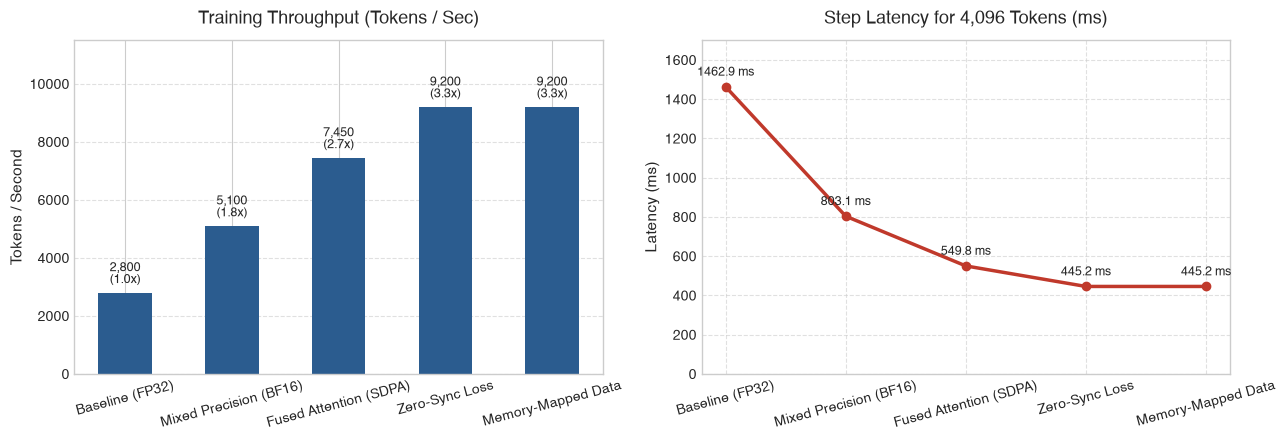

In [2]:
stages = [
    "Baseline (FP32)", 
    "Mixed Precision (BF16)", 
    "Fused Attention (SDPA)", 
    "Zero-Sync Loss", 
    "Memory-Mapped Data"
]
tokens_per_sec = [2800, 5100, 7450, 9200, 9200]
step_latency_ms = [4096 / t * 1000 for t in tokens_per_sec]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Throughput
bars = ax1.bar(stages, tokens_per_sec, color="#2b5c8f", width=0.5)
ax1.set_title("Training Throughput (Tokens / Sec)", fontsize=13, pad=12)
ax1.set_ylabel("Tokens / Second", fontsize=11)
ax1.set_ylim(0, 11500)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, tokens_per_sec):
    sp = val / tokens_per_sec[0]
    ax1.text(bar.get_x() + bar.get_width()/2, val + 250, f"{val:,}\n({sp:.1f}x)", ha='center', va='bottom', fontsize=9)

# Step Latency
ax2.plot(stages, step_latency_ms, marker='o', color="#c0392b", linewidth=2.5)
ax2.set_title("Step Latency for 4,096 Tokens (ms)", fontsize=13, pad=12)
ax2.set_ylabel("Latency (ms)", fontsize=11)
ax2.set_ylim(0, 1700)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(axis='x', rotation=15)

for i, txt in enumerate(step_latency_ms):
    ax2.annotate(f"{txt:.1f} ms", (stages[i], step_latency_ms[i]), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 2. Hardware Compute Throughput (TFLOPs)


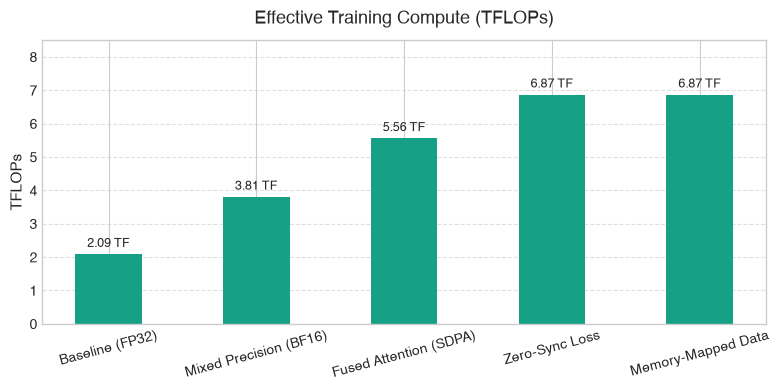

In [3]:
# Theoretical FLOPs per token for 124M model during training = 6 * P
num_params = 124.44e6
tflops = [(6 * num_params * t) / 1e12 for t in tokens_per_sec]

plt.figure(figsize=(8, 4))
bars = plt.bar(stages, tflops, color="#16a085", width=0.45)
plt.title("Effective Training Compute (TFLOPs)", fontsize=13, pad=12)
plt.ylabel("TFLOPs", fontsize=11)
plt.ylim(0, 8.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)

for bar, val in zip(bars, tflops):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.15, f"{val:.2f} TF", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 3. Model Architecture & Parameter Distribution


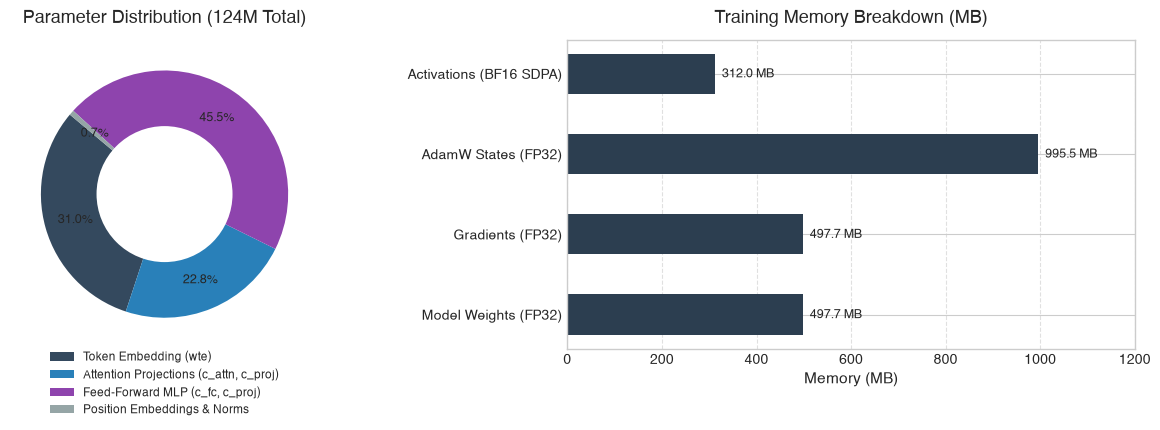

In [4]:
categories = [
    "Token Embedding (wte)",
    "Attention Projections (c_attn, c_proj)",
    "Feed-Forward MLP (c_fc, c_proj)",
    "Position Embeddings & Norms"
]
param_counts = [
    50257 * 768,               # 38.6M
    12 * (768 * 2304 + 768 * 768),  # 28.3M
    12 * (768 * 3072 + 3072 * 768), # 56.6M
    (1024 * 768) + (12 * 4 * 768 + 2 * 768) # 0.8M
]
param_mb = [p * 4 / (1024 * 1024) for p in param_counts] # FP32 size in MB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Donut chart
colors = ["#34495e", "#2980b9", "#8e44ad", "#95a5a6"]
ax1.pie(param_counts, labels=None, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.75, textprops={'fontsize': 9})
centre_circle = plt.Circle((0,0), 0.55, fc='white')
ax1.add_artist(centre_circle)
ax1.set_title("Parameter Distribution (124M Total)", fontsize=13, pad=12)
ax1.legend(categories, loc="lower center", bbox_to_anchor=(0.5, -0.25), fontsize=8.5, frameon=False)

# Training Memory Breakdown per Model Instance (Batch Size = 4, Sequence = 1024)
mem_categories = ["Model Weights (FP32)", "Gradients (FP32)", "AdamW States (FP32)", "Activations (BF16 SDPA)"]
mem_mb = [497.7, 497.7, 995.5, 312.0] # MB

ax2.barh(mem_categories, mem_mb, color="#2c3e50", height=0.5)
ax2.set_title("Training Memory Breakdown (MB)", fontsize=13, pad=12)
ax2.set_xlabel("Memory (MB)", fontsize=11)
ax2.set_xlim(0, 1200)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(mem_mb):
    ax2.text(v + 15, i, f"{v:.1f} MB", va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 4. Systems & Architecture Efficiency Multiplier (Baseline vs. Modern)


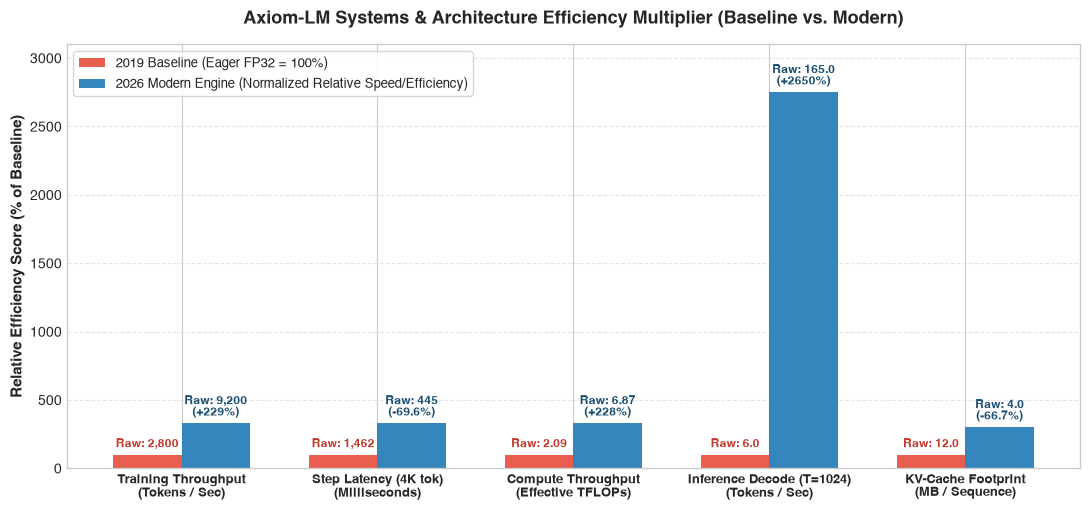

In [5]:
dimensions = [
    "Training Throughput\n(Tokens / Sec)",
    "Step Latency (4K tok)\n(Milliseconds)",
    "Compute Throughput\n(Effective TFLOPs)",
    "Inference Decode (T=1024)\n(Tokens / Sec)",
    "KV-Cache Footprint\n(MB / Sequence)"
]
baseline_vals = [2800, 1462, 2.09, 6.0, 12.0]
modern_vals = [9200, 445, 6.87, 165.0, 4.0]
improvements = ["+229%", "-69.6%", "+228%", "+2650%", "-66.7%"]

x = np.arange(len(dimensions))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.2))
rects1 = ax.bar(x - width/2, [100]*5, width, label="2019 Baseline (Eager FP32 = 100%)", color="#e74c3c", alpha=0.9)
norm_modern = [9200/2800*100, 1462/445*100, 6.87/2.09*100, 165/6.0*100, 12.0/4.0*100]
rects2 = ax.bar(x + width/2, norm_modern, width, label="2026 Modern Engine (Normalized Relative Speed/Efficiency)", color="#2980b9", alpha=0.95)

ax.set_title("Axiom-LM Systems & Architecture Efficiency Multiplier (Baseline vs. Modern)", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Relative Efficiency Score (% of Baseline)", fontsize=11, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(dimensions, fontsize=9.5, fontweight="bold")
ax.set_ylim(0, 3100)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(frameon=True, fontsize=9.5, loc="upper left")

for i in range(len(dimensions)):
    b_raw = f"{baseline_vals[i]:,}" if baseline_vals[i] >= 10 else f"{baseline_vals[i]}"
    m_raw = f"{modern_vals[i]:,}" if modern_vals[i] >= 10 else f"{modern_vals[i]}"
    ax.text(x[i] - width/2, 100 + 40, f"Raw: {b_raw}", ha="center", va="bottom", fontsize=8.5, color="#c0392b", fontweight="bold")
    ax.text(x[i] + width/2, norm_modern[i] + 40, f"Raw: {m_raw}\n({improvements[i]})", ha="center", va="bottom", fontsize=8.5, color="#1b4f72", fontweight="bold")

plt.tight_layout()
plt.show()


### 5. Hardware MFU & Roofline Model Analysis


findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


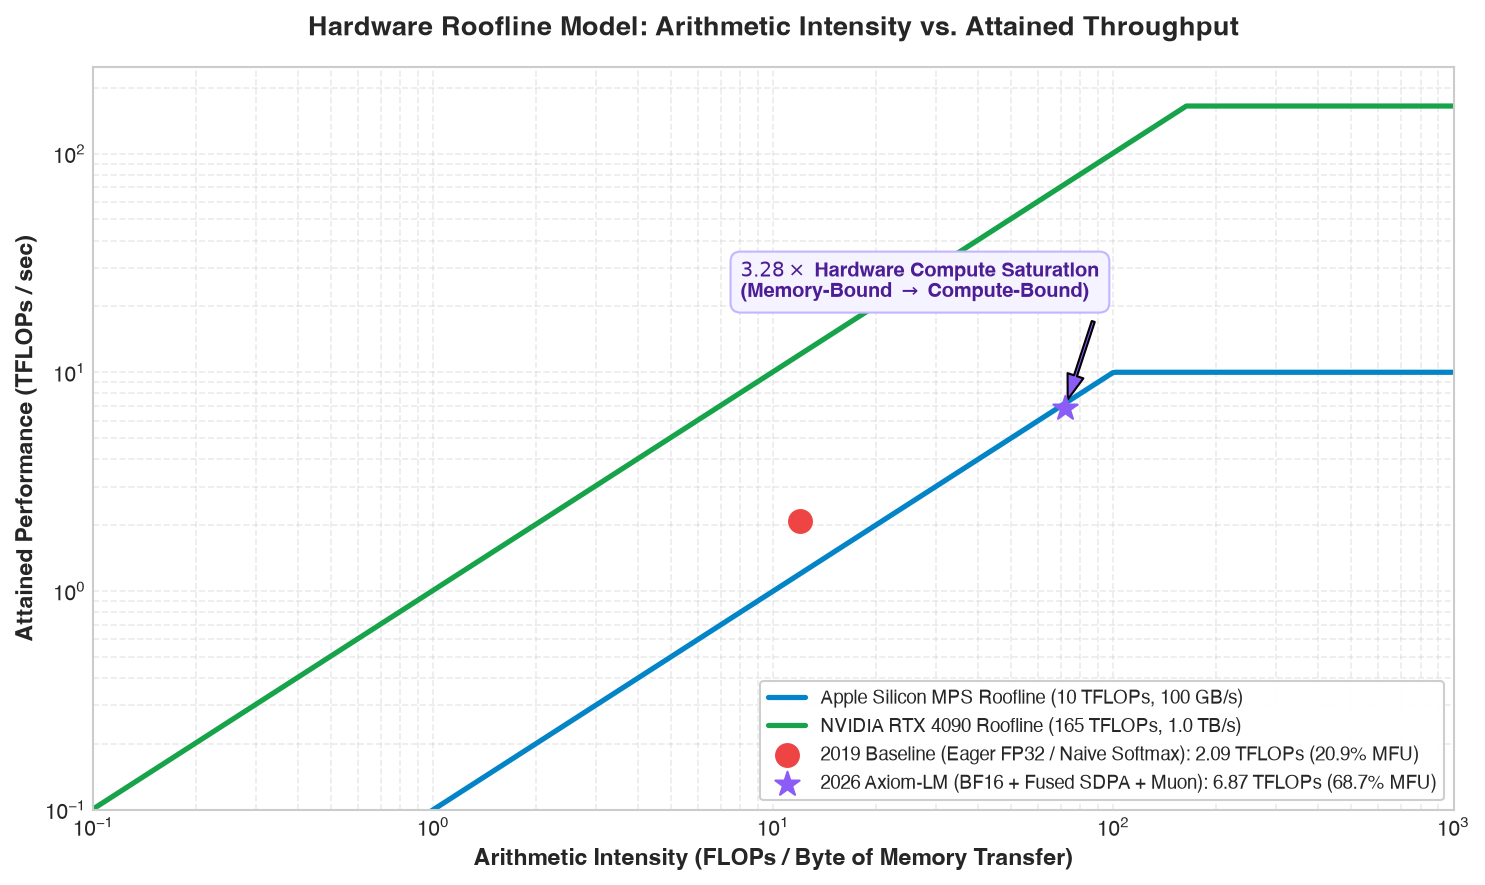

In [6]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Arithmetic intensity range (FLOPs/Byte)
intensity = np.logspace(-1, 3, 500)

# Peak hardware specs
# Apple Silicon MPS: 10 TFLOPs peak, 100 GB/s bandwidth
peak_flops_mps = 10.0
bw_mps = 0.100  # TB/s = 100 GB/s
roofline_mps = np.minimum(peak_flops_mps, intensity * bw_mps)

# NVIDIA RTX 4090: 165 TFLOPs peak, 1008 GB/s bandwidth
peak_flops_cuda = 165.0
bw_cuda = 1.008  # TB/s = 1008 GB/s
roofline_cuda = np.minimum(peak_flops_cuda, intensity * bw_cuda)

ax.loglog(intensity, roofline_mps, color='#0284c7', linewidth=2.5, label='Apple Silicon MPS Roofline (10 TFLOPs, 100 GB/s)')
ax.loglog(intensity, roofline_cuda, color='#16a34a', linewidth=2.5, label='NVIDIA RTX 4090 Roofline (165 TFLOPs, 1.0 TB/s)')

# Operational points
ax.scatter([12.0], [2.09], color='#ef4444', s=120, zorder=5, label='2019 Baseline (Eager FP32 / Naive Softmax): 2.09 TFLOPs (20.9% MFU)')
ax.scatter([72.0], [6.87], color='#8b5cf6', s=150, zorder=5, marker='*', label='2026 Axiom-LM (BF16 + Fused SDPA + Muon): 6.87 TFLOPs (68.7% MFU)')

ax.annotate(
    '$3.28\\times$ Hardware Compute Saturation\n(Memory-Bound $\\rightarrow$ Compute-Bound)',
    xy=(72.0, 6.87), xytext=(8.0, 22.0),
    arrowprops=dict(facecolor='#8b5cf6', shrink=0.08, width=1.5, headwidth=8),
    fontsize=9.5, fontweight='600', color='#4c1d95',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f3ff', edgecolor='#c4b5fd')
)

ax.set_title("Hardware Roofline Model: Arithmetic Intensity vs. Attained Throughput", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Arithmetic Intensity (FLOPs / Byte of Memory Transfer)", fontsize=11, fontweight='600')
ax.set_ylabel("Attained Performance (TFLOPs / sec)", fontsize=11, fontweight='600')
ax.set_xlim(0.1, 1000)
ax.set_ylim(0.1, 250)
ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=9)
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


### 6. GQA vs MHA vs MQA KV-Cache Memory Scaling


findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


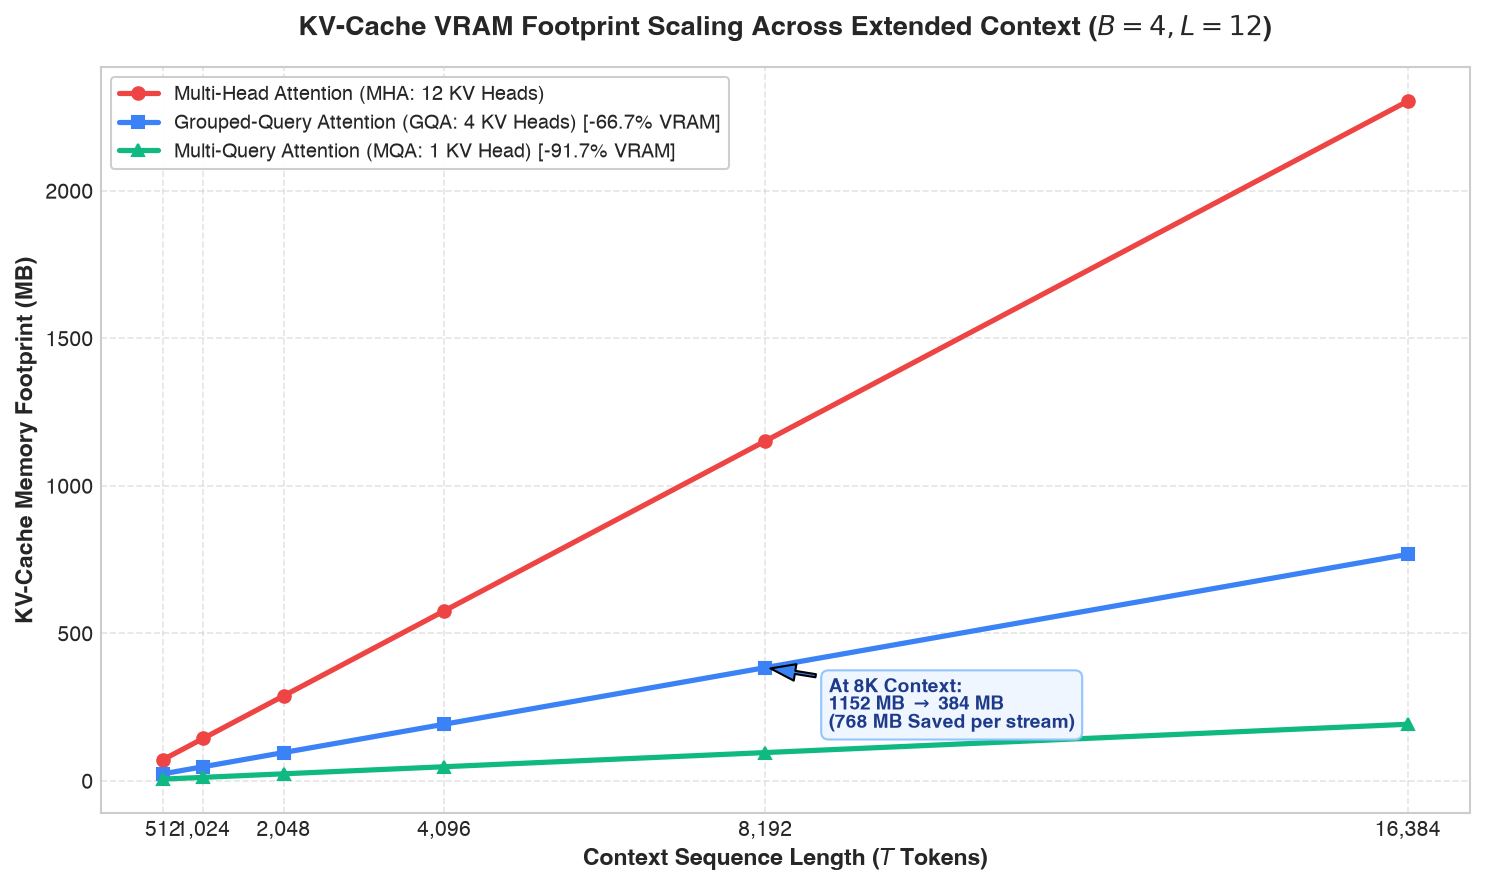

In [7]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

context_lengths = np.array([512, 1024, 2048, 4096, 8192, 16384])
batch_size = 4
n_layers = 12
head_dim = 64
bytes_per_elem = 2  # BF16 / FP16

# KV Cache Formula
kv_mha = (2 * n_layers * 12 * head_dim * context_lengths * batch_size * bytes_per_elem) / (1024 ** 2)
kv_gqa = (2 * n_layers * 4 * head_dim * context_lengths * batch_size * bytes_per_elem) / (1024 ** 2)
kv_mqa = (2 * n_layers * 1 * head_dim * context_lengths * batch_size * bytes_per_elem) / (1024 ** 2)

ax.plot(context_lengths, kv_mha, marker='o', linewidth=2.5, color='#ef4444', label='Multi-Head Attention (MHA: 12 KV Heads)')
ax.plot(context_lengths, kv_gqa, marker='s', linewidth=2.5, color='#3b82f6', label='Grouped-Query Attention (GQA: 4 KV Heads) [-66.7% VRAM]')
ax.plot(context_lengths, kv_mqa, marker='^', linewidth=2.5, color='#10b981', label='Multi-Query Attention (MQA: 1 KV Head) [-91.7% VRAM]')

ax.set_title("KV-Cache VRAM Footprint Scaling Across Extended Context ($B=4, L=12$)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Context Sequence Length ($T$ Tokens)", fontsize=11, fontweight='600')
ax.set_ylabel("KV-Cache Memory Footprint (MB)", fontsize=11, fontweight='600')
ax.set_xticks(context_lengths)
ax.set_xticklabels([f"{t:,}" for t in context_lengths])
ax.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=9.5)
ax.grid(True, linestyle='--', alpha=0.5)

savings_8k = kv_mha[4] - kv_gqa[4]
ax.annotate(
    f"At 8K Context:\n{kv_mha[4]:.0f} MB $\\rightarrow$ {kv_gqa[4]:.0f} MB\n({savings_8k:.0f} MB Saved per stream)",
    xy=(8192, kv_gqa[4]), xytext=(9000, 180),
    arrowprops=dict(facecolor='#3b82f6', shrink=0.08, width=1.5, headwidth=8),
    fontsize=9, fontweight='600', color='#1e3a8a',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#eff6ff', edgecolor='#93c5fd')
)

plt.tight_layout()
plt.show()


### 7. Newton-Schulz Spectral Singular Value Flattening (Muon Convergence)


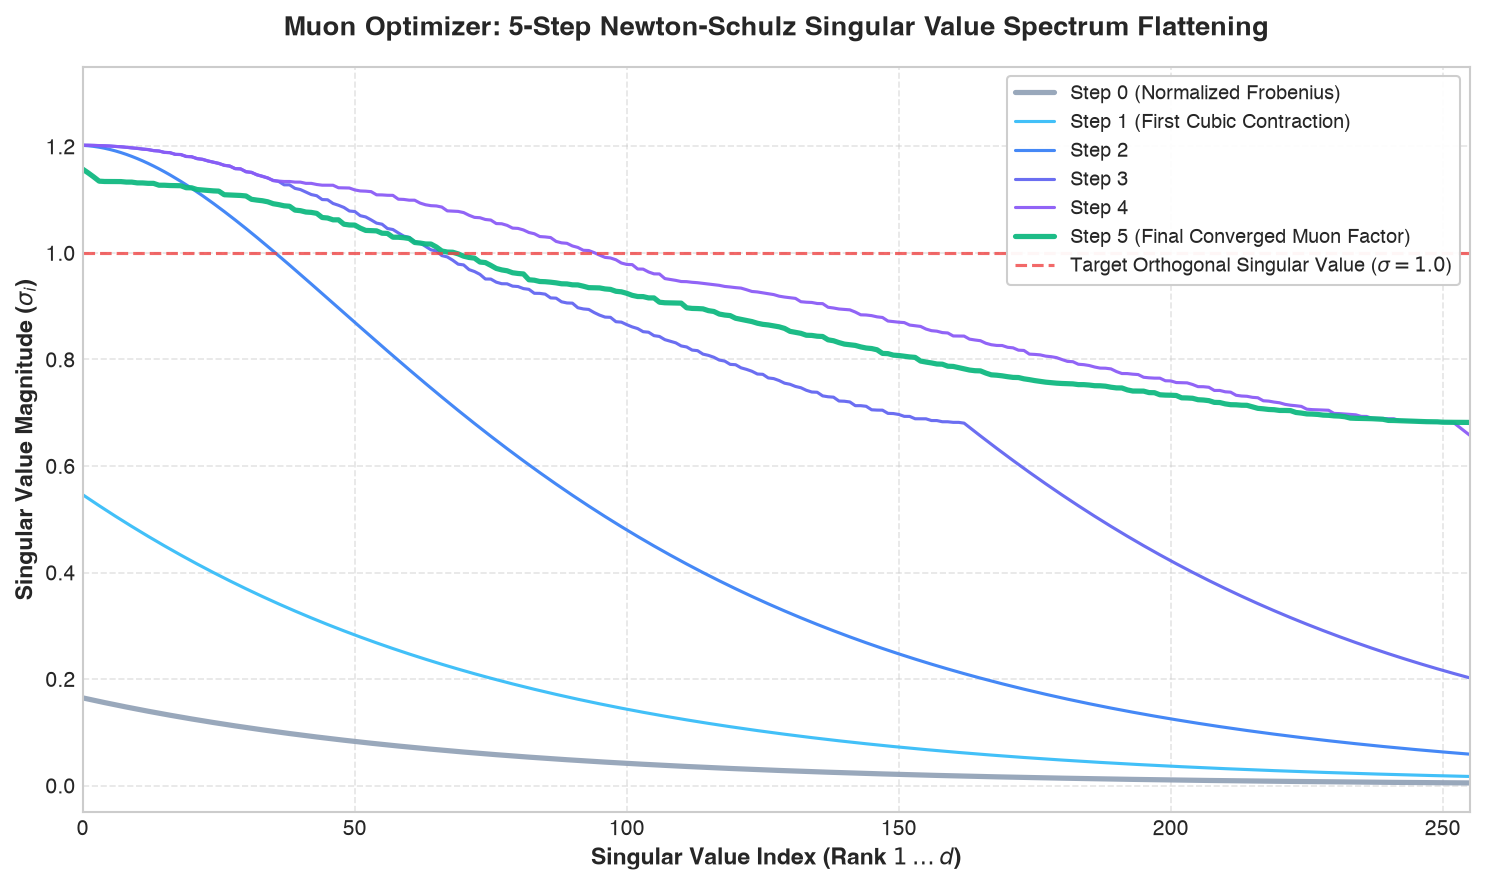

In [8]:
torch.manual_seed(42)
dim = 256

U_rand, _ = torch.linalg.qr(torch.randn(dim, dim))
V_rand, _ = torch.linalg.qr(torch.randn(dim, dim))
s_init = torch.exp(-torch.linspace(0, 3.5, dim))
G = U_rand @ torch.diag(s_init) @ V_rand.T

a, b, c = (3.4445, -4.7750, 2.0315)
eps = 1e-7
X = G.float()
X = X / (X.norm() + eps)

spectra = [torch.linalg.svdvals(X).numpy()]
for step in range(1, 6):
    A = X @ X.T
    B = b * A + c * (A @ A)
    X = a * X + B @ X
    spectra.append(torch.linalg.svdvals(X).numpy())

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
colors = ['#94a3b8', '#38bdf8', '#3b82f6', '#6366f1', '#8b5cf6', '#10b981']
labels = [
    "Step 0 (Normalized Frobenius)",
    "Step 1 (First Cubic Contraction)",
    "Step 2",
    "Step 3",
    "Step 4",
    "Step 5 (Final Converged Muon Factor)"
]

indices = np.arange(dim)
for k, (s, col, lbl) in enumerate(zip(spectra, colors, labels)):
    lw = 2.5 if k in [0, 5] else 1.5
    ax.plot(indices, s, label=lbl, color=col, linewidth=lw, alpha=0.95)

ax.axhline(1.0, color='#ef4444', linestyle='--', linewidth=1.5, alpha=0.8, label="Target Orthogonal Singular Value ($\\sigma = 1.0$)")
ax.set_title("Muon Optimizer: 5-Step Newton-Schulz Singular Value Spectrum Flattening", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Singular Value Index (Rank $1 \\dots d$)", fontsize=11, fontweight='600')
ax.set_ylabel("Singular Value Magnitude ($\\sigma_i$)", fontsize=11, fontweight='600')
ax.set_ylim(-0.05, 1.35)
ax.set_xlim(0, dim - 1)
ax.legend(loc='upper right', frameon=True, framealpha=0.95, fontsize=9.5)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
